In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"
import jax
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
jr.init_cluster()

#parameters
nx = 32
ny = 32
nz = 32
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi
t = 0.0
nsnap = 100
t_snap = 0.1
t_end = 1.0
cfl_safety = 0.5 #this is pretty aggressive
spatial_dimensions=3
snap_path="data/physics_engine_tests/"

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3

x = jnp.linspace(0, Lx, nx, endpoint=False)
y = jnp.linspace(0, Ly, ny, endpoint=False)
z = jnp.linspace(0, Lz, nz, endpoint=False)

x_grid = x.reshape(1,-1,1)
y_grid = y.reshape(1,1,-1)
z_grid = z.reshape(-1,1,1)


#initialize arrays
#modified Orzag-Tang vortex as described in Loureiro et al. 2016 (Viriato paper)
phi = (jnp.cos(x_grid+1.4) + jnp.cos(y_grid+0.5)) * jnp.sin(z_grid)
psi = (jnp.cos(2.0*x_grid+2.3) + jnp.cos(y_grid + 4.1)) * jnp.cos(z_grid)

#fft
phik=ft.rfft2(phi)
psik=ft.rfft2(psi)

#set up orbax snapshot manager
mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
params=jr.Parameters(nx=nx,ny=ny,nz=nz,Lx=Lx,Ly=Ly,Lz=Lz,diss=(visc,res),hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions)
kgrid = jr.setup_kgrids(params)
state = jax.device_put(jr.SimulationState(t=0.0,fields=jnp.stack((phik,psik))),params.state_sharding)

nblock = jr.estimate_good_nblock(state,kgrid,params,t_snap,t_end,nblock_min=1)
print("nblock estimate: "+str(nblock))

rmhd-solver has initialized jax in 64bit precision.
Running in local mode. Total devices: 4


nblock estimate: 2


In [2]:
jr.simulate_scan(state,kgrid,params,nblock,t_snap=t_snap,t_end=t_end,mngr=mngr)

Saving initial state as snapshot 0
0.09038576707347268
0.18021973709400402
Saving snapshot 1
0.2692495150344861
0.3573259652519882
Saving snapshot 2
0.4444609419187659
0.5288924227656635
Saving snapshot 3
0.6103327258879956
0.6875359539707803
Saving snapshot 4
0.7602027426323583
0.829161253957402
Saving snapshot 5
0.8948042100707079
0.9577024437946584
Saving snapshot 6
1.0188525285594905
Saving final state as snapshot 7
Ending simulation at t = 1.0188525285594905. It took 0.848180916858837s


SimulationState(t=Array(1.01885253, dtype=float64), fields=Array([[[[-7.79855216e-15+0.00000000e+00j,
           2.02868474e+00-7.20736470e-01j,
           6.13609567e-03+7.59753604e-03j, ...,
          -2.39048612e-16-8.46763336e-16j,
          -9.52300249e-15-1.05082226e-15j,
          -4.16391022e-17+0.00000000e+00j],
         [-1.89138681e+00+1.47325316e+00j,
           5.68281831e+01-5.56610018e+01j,
          -3.84027937e+00+1.98315405e+00j, ...,
           3.13540233e-16+1.30343961e-15j,
           1.05460235e-15-2.93257373e-15j,
          -6.13466289e-16-2.85472354e-15j],
         [-1.47277650e-01-1.85737134e-01j,
           1.10229153e+02-1.10201956e+01j,
           8.57974058e-01+7.76006223e-01j, ...,
           7.73542619e-16+1.97271157e-15j,
          -4.17380394e-16-2.36715868e-16j,
          -2.09783687e-16-9.91434780e-16j],
         ...,
         [ 5.05748593e-01+7.97099488e-01j,
           3.97041136e+00+3.70103889e+00j,
          -7.85899987e-01-3.40374426e+00j, ...,
 

In [3]:
s=jr.simulate(state,kgrid,params,t_snap,t_end,mngr)

Saving initial state as snapshot 0
State sharding entering jit: NamedSharding(mesh=Mesh('z_axis': 4, axis_types=(Auto,)), spec=P(None, 'z_axis', None, None), memory_kind=device)
State sharding exiting jit: NamedSharding(mesh=Mesh('z_axis': 4, axis_types=(Auto,)), spec=P(None, 'z_axis', None, None), memory_kind=device)
Saving snapshot 1 at t = 0.1354656076445698
State sharding entering jit: NamedSharding(mesh=Mesh('z_axis': 4, axis_types=(Auto,)), spec=P(None, 'z_axis', None, None), memory_kind=device)
State sharding exiting jit: NamedSharding(mesh=Mesh('z_axis': 4, axis_types=(Auto,)), spec=P(None, 'z_axis', None, None), memory_kind=device)
Saving snapshot 2 at t = 0.2692495150344861
State sharding entering jit: NamedSharding(mesh=Mesh('z_axis': 4, axis_types=(Auto,)), spec=P(None, 'z_axis', None, None), memory_kind=device)
State sharding exiting jit: NamedSharding(mesh=Mesh('z_axis': 4, axis_types=(Auto,)), spec=P(None, 'z_axis', None, None), memory_kind=device)
Saving snapshot 3 at t

In [4]:
vort=ft.irfft2(-kgrid.ksq()*s.fields[0,:,:,:])

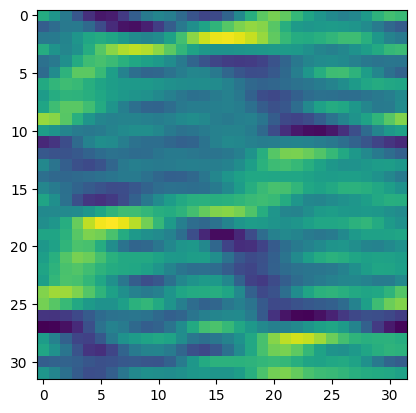

In [5]:
plt.imshow(vort[39,:,:])

In [6]:
from jax.debug import visualize_array_sharding

# Slicing a 2D plane (index 0 of nfields, all nz, index 0 of nkx, all nky)
visualize_array_sharding(s.fields[:, :, 0, 0])

In [17]:
import jax
import jax_rmhd.timestepping as ts
from functools import partial
stepper,scheme=ts.get_scheme("lsrk33")
# 1. Create a tiny test function that mirrors your real-space to k-space FFT pipeline
@partial(jax.jit,static_argnums=(2,3,4,5))
def check_hlo(state,kgrid,params,nblock,scheme,stepper):
    # This matches the rfft2 behavior on the last two axes
    return jr.run.block_of_steps(state,kgrid,params,nblock,scheme,stepper)

# 2. Lower and compile using your actual sharded array as a template
# (Assuming `sample_field` is an array already sharded with fields_sharding)
lowered = check_hlo.lower(state,kgrid,params,nblock,scheme,stepper)
compiled = lowered.compile()

# 3. Extract the text representation of XLA's optimized execution plan
hlo_text = compiled.as_text()

# 4. Search for cross-device communication operations
communication_ops = ["all-to-all", "all-gather", "reduce-scatter", "collective-permute"]
has_communication = False

print("Checking XLA HLO for cross-device communication...")
for op in communication_ops:
    if op in hlo_text.lower():
        print(f"⚠️ FOUND: {op} is happening!")
        has_communication = True

if not has_communication:
    print("✅ Success! No cross-device communication found.")

Checking XLA HLO for cross-device communication...
⚠️ FOUND: collective-permute is happening!


In [16]:
# Assuming hlo_text is what you captured from `compiled.as_text()`
lines = hlo_text.split('\n')

print("=== TARGETED HLO COMM ANALYSIS ===")
for i, line in enumerate(lines):
    # Highlight cross-device operations
    if any(op in line for op in ["all-gather", "all-to-all", "collective-permute"]):
        print(f"\n[LINE {i}] 通信発生 (COMMUNICATION EVENT):")
        
        # Print a 3-line window BEFORE the communication to see what triggered it
        for j in range(max(0, i-3), i):
            print(f"  (Pre-op)  {lines[j].strip()}")
            
        print(f"  👉 💥 {line.strip()}")
        
        # Print a 3-line window AFTER the communication to see where data went
        for j in range(i+1, min(len(lines), i+4)):
            print(f"  (Post-op) {lines[j].strip()}")

=== TARGETED HLO COMM ANALYSIS ===

[LINE 602] 通信発生 (COMMUNICATION EVENT):
  (Pre-op)  %wrapped_slice.5 = c128[2,1,32,17]{3,2,1,0} fusion(%get-tuple-element.82), kind=kLoop, calls=%wrapped_slice_computation.5, metadata={op_name="jit(check_hlo)/while/body/closed_call/while/body/closed_call/cond/branch_0_fun/jit(_roll_static)/concatenate" stack_frame_id=196}
  (Pre-op)  %wrapped_slice.4 = c128[2,2,32,17]{3,2,1,0} fusion(%get-tuple-element.82), kind=kLoop, calls=%wrapped_slice_computation.4, metadata={op_name="jit(check_hlo)/while/body/closed_call/while/body/closed_call/cond/branch_0_fun/jit(_roll_static)/concatenate" stack_frame_id=198}
  (Pre-op)  %bitcast_concatenate_fusion.1 = c128[4,2,8,32,17]{4,3,2,1,0} fusion(%bitcast_concatenate_fusion.2, %get-tuple-element.81, %get-tuple-element.80), kind=kLoop, calls=%fused_computation.6, metadata={op_name="jit(check_hlo)/while/body/closed_call/while/body/closed_call/cond/branch_0_fun/concatenate" stack_frame_id=160}, backend_config={"outer_dime

In [15]:
lines

['HloModule jit_check_hlo, is_scheduled=true, entry_computation_layout={(f64[], c128[2,8,32,17]{3,2,1,0}, f64[32,1]{1,0}, f64[1,17]{1,0})->(f64[], c128[2,8,32,17]{3,2,1,0})}, allow_spmd_sharding_propagation_to_parameters={false,false,true,true}, allow_spmd_sharding_propagation_to_output={true,true}, num_partitions=4',
 '',
 'FileNames',
 '1 "<frozen runpy>"',
 '2 "/var/folders/c1/mrll_5zs01j4m9bz9ryks59h0000gn/T/ipykernel_81228/1485425266.py"',
 '3 "/Users/alfy/jax_rmhd/jax_rmhd/run.py"',
 '4 "/Users/alfy/jax_rmhd/jax_rmhd/timestepping.py"',
 '5 "/Users/alfy/jax_rmhd/jax_rmhd/physics/__init__.py"',
 '6 "/Users/alfy/jax_rmhd/jax_rmhd/physics/rmhd.py"',
 '7 "/Users/alfy/jax_rmhd/jax_rmhd/fourier.py"',
 '8 "/Users/alfy/jax_rmhd/jax_rmhd/physics/shared_physics.py"',
 '',
 'FunctionNames',
 '1 "_run_module_as_main"',
 '2 "_run_code"',
 '3 "<module>"',
 '4 "check_hlo"',
 '5 "block_of_steps"',
 '6 "block_of_steps.<locals>.stepping"',
 '7 "lsrk_advance"',
 '8 "construct_rhs.<locals>.rhs"',
 '9